In [24]:
import torch
from torchvision import transforms

PARTE 2: PREPARACIÓN DATASET

In [25]:
# transformaciones para entrenamiento

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transformaciones para validación y test
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

PARTE 3: CARGAR EL DATASET

In [26]:
import os
from google.colab import drive
drive.mount('/content/drive')
from torchvision import datasets
from torch.utils.data import DataLoader, random_split


ruta_externa = '/content/drive/MyDrive/dataset_kaggle_final/'

train_set = datasets.ImageFolder(root=ruta_externa + 'train/', transform=transform_train)
val_set   = datasets.ImageFolder(root=ruta_externa + 'val/',   transform=transform_val)
test_set  = datasets.ImageFolder(root=ruta_externa + 'test/',  transform=transform_val)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

print(f"Clases: {train_set.classes}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 1698 | Val: 361 | Test: 370
Clases: ['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


PARTE 4: CARGAR DATOS

In [27]:
train_loader = DataLoader(train_set, batch_size = 16, shuffle=True)
val_loader = DataLoader(val_set, batch_size = 16, shuffle=False)
test_loader = DataLoader(test_set, batch_size = 16, shuffle=False)

print(f"Batches en train: {len(train_loader)}")
print(f"Batches en val: {len(val_loader)}")
print(f"Batches en test: {len(test_loader)}")


Batches en train: 107
Batches en val: 23
Batches en test: 24


PARTE 5: ARQUITECTURA CNN

In [28]:
import torch.nn as nn

class BaselineCNN(nn.Module):
  def __init__(self, num_classes=6, dropout_rate=0.5):
    super(BaselineCNN, self).__init__()


    # extracción características

    # bloque 1 : 3 canales RGB --> 32 filtros

    self.bloque1 = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(dropout_rate)
    )

    # bloque 2 : 32 filtros --> 64

    self.bloque2 = nn.Sequential(
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(dropout_rate)
    )

    # bloque 3 : 64 filtros -> 128 filtros

    self.bloque3 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(dropout_rate)
    )


    # clasificación

    self.clasificador = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 28 * 28, 256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    x = self.bloque1(x)
    x = self.bloque2(x)
    x = self.bloque3(x)
    x = self.clasificador(x)
    return x

In [29]:
modelo = BaselineCNN(num_classes=6, dropout_rate=0.5)
print(modelo)

BaselineCNN(
  (bloque1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=False)
  )
  (bloque3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=F

In [30]:
# vamos a probar que la red funciona con el tamaño de la imágenes

imagen_prueba = torch.randn(1, 3, 224, 224)
with torch.no_grad():
  salida = modelo(imagen_prueba)

print(imagen_prueba.shape)
print(salida.shape)


torch.Size([1, 3, 224, 224])
torch.Size([1, 6])


PARTE 6: ENTRENAMIENTO Y VALIDACIÓN



In [31]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = modelo.to(device)

criterio = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.001)
epochs = 20

hist_loss_train = []
hist_acc_train = [] # Nueva lista para la precisión de entrenamiento
hist_loss_val = []  # Nueva lista para la pérdida de validación
hist_acc_val = []

for epoch in range(epochs):

  # ENTRNAMIENTO

  modelo.train()
  loss_total_train = 0
  correctas_train = 0 # Para precisión de entrenamiento
  total_train = 0     # Para precisión de entrenamiento

  for imagenes, etiquetas in train_loader:
    imagenes = imagenes.to(device)
    etiquetas = etiquetas.to(device)

    optimizer.zero_grad() # resetea gradientes
    salida = modelo(imagenes) # forward pass
    loss = criterio(salida, etiquetas) # calcula error
    loss.backward() # backward pass
    optimizer.step() # actualizar pesos

    loss_total_train += loss.item()

    # Calcular precisión en entrenamiento
    _, predicciones_train = torch.max(salida, 1)
    correctas_train += (predicciones_train == etiquetas).sum().item()
    total_train += etiquetas.size(0)

  loss_medio_train = loss_total_train / len(train_loader)
  acc_train = correctas_train / total_train


  # fase de validación

  modelo.eval()
  correctas_val = 0
  total_val = 0
  loss_total_val = 0 # Para pérdida de validación

  with torch.no_grad():
    for imagenes, etiquetas in val_loader:
      imagenes = imagenes.to(device)
      etiquetas = etiquetas.to(device)
      salida = modelo(imagenes)
      loss_val = criterio(salida, etiquetas) # Calcula la pérdida de validación
      loss_total_val += loss_val.item()

      _, predicciones_val = torch.max(salida, 1)
      correctas_val += (predicciones_val == etiquetas).sum().item()
      total_val += etiquetas.size(0)

  loss_medio_val = loss_total_val / len(val_loader)
  acc_val = correctas_val / total_val

  hist_loss_train.append(loss_medio_train)
  hist_acc_train.append(acc_train) # Añadir precisión de entrenamiento
  hist_loss_val.append(loss_medio_val) # Añadir pérdida de validación
  hist_acc_val.append(acc_val)

  print(f"Epoch: {epoch+1}/{epochs}")
  print(f"Loss train: {loss_medio_train:.4f} | Acc train: {acc_train:.4f}")
  print(f"Loss val:   {loss_medio_val:.4f} | Acc val:   {acc_val:.4f}")

Epoch: 1/20
Loss train: 7.3054 | Acc train: 0.2256
Loss val:   1.6822 | Acc val:   0.3019
Epoch: 2/20
Loss train: 1.7247 | Acc train: 0.2750
Loss val:   1.6782 | Acc val:   0.3075
Epoch: 3/20
Loss train: 1.6924 | Acc train: 0.2780
Loss val:   1.6624 | Acc val:   0.3213
Epoch: 4/20
Loss train: 1.6877 | Acc train: 0.2721
Loss val:   1.6281 | Acc val:   0.3075
Epoch: 5/20
Loss train: 1.6790 | Acc train: 0.2786
Loss val:   1.6310 | Acc val:   0.3296
Epoch: 6/20
Loss train: 1.6554 | Acc train: 0.2856
Loss val:   1.6218 | Acc val:   0.3463
Epoch: 7/20
Loss train: 1.6652 | Acc train: 0.2903
Loss val:   1.6207 | Acc val:   0.3407
Epoch: 8/20
Loss train: 1.6345 | Acc train: 0.2992
Loss val:   1.5776 | Acc val:   0.3490
Epoch: 9/20
Loss train: 1.6265 | Acc train: 0.2974
Loss val:   1.6255 | Acc val:   0.3241
Epoch: 10/20
Loss train: 1.6316 | Acc train: 0.2921
Loss val:   1.5929 | Acc val:   0.3380
Epoch: 11/20
Loss train: 1.6120 | Acc train: 0.2974
Loss val:   1.6069 | Acc val:   0.3380
Epoch: 1

PARTE 7: GRÁFICOS

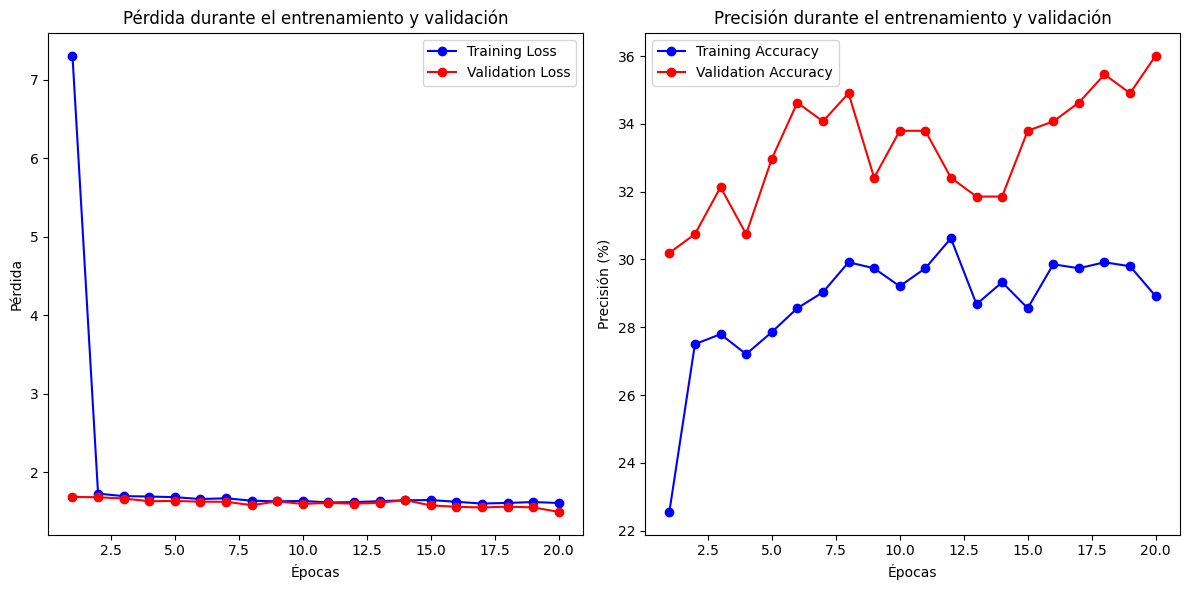

In [32]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs +1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de Pérdida (Train y Val)
ax1.plot(epochs_range, hist_loss_train, 'b-o', label='Training Loss')
ax1.plot(epochs_range, hist_loss_val, 'r-o', label='Validation Loss')
ax1.set_title("Pérdida durante el entrenamiento y validación")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Pérdida")
ax1.legend()

# Gráfico de Precisión (Train y Val)
ax2.plot(epochs_range, [a * 100 for a in hist_acc_train], 'b-o', label='Training Accuracy')
ax2.plot(epochs_range, [a * 100 for a in hist_acc_val], 'r-o', label='Validation Accuracy')
ax2.set_title("Precisión durante el entrenamiento y validación")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Precisión (%)")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score

modelo.eval()
todas_predicciones = []
todas_etiquetas = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)
        salida = modelo(imagenes)
        _, predicciones = torch.max(salida, 1)
        todas_predicciones.extend(predicciones.cpu().numpy())
        todas_etiquetas.extend(etiquetas.cpu().numpy())

acc_test = sum(p == e for p, e in zip(todas_predicciones, todas_etiquetas)) / len(todas_etiquetas) * 100
f1_test = f1_score(todas_etiquetas, todas_predicciones, average='macro')

print(f"Accuracy en TEST:  {acc_test:.2f}%")
print(f"Macro F1 Score:    {f1_test:.4f}")

Accuracy en TEST:  31.89%
Macro F1 Score:    0.1900


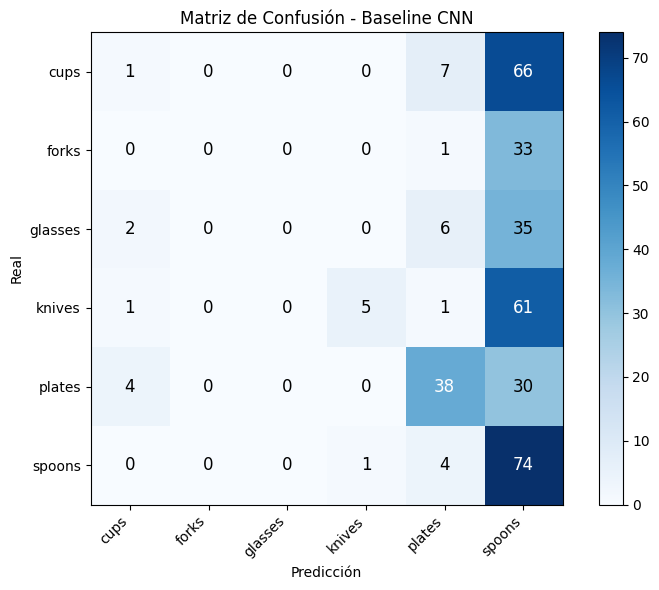


Total imágenes mal clasificadas: 252


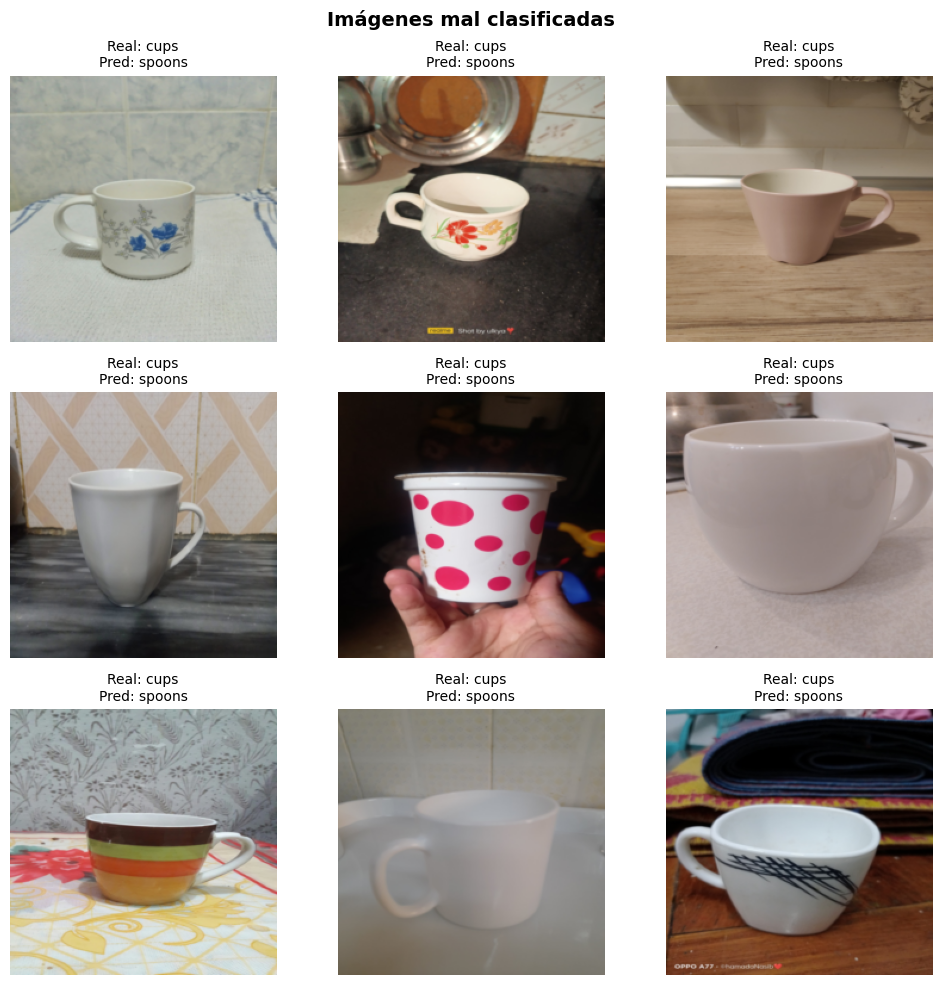

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.metrics import confusion_matrix
import numpy as np

# ── 1. CONFUSION MATRIX ──────────────────────────────────────────
cm = confusion_matrix(todas_etiquetas, todas_predicciones)
clases_nombres = train_set.classes

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(len(clases_nombres)))
ax.set_yticks(range(len(clases_nombres)))
ax.set_xticklabels(clases_nombres, rotation=45, ha='right')
ax.set_yticklabels(clases_nombres)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión - Baseline CNN')

# Números dentro de cada celda
for i in range(len(clases_nombres)):
    for j in range(len(clases_nombres)):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 2. IMÁGENES MAL CLASIFICADAS ─────────────────────────────────
# Buscamos índices donde la predicción fue incorrecta
errores = [(i, p, e) for i, (p, e) in enumerate(zip(todas_predicciones, todas_etiquetas)) if p != e]
print(f"\nTotal imágenes mal clasificadas: {len(errores)}")

# Mostramos las primeras 9
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for idx, (i, pred, real) in enumerate(errores[:9]):
    imagen, _ = test_set[i]
    # Desnormalizamos para visualizar
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    imagen = imagen * std[:, None, None] + mean[:, None, None]
    imagen = imagen.permute(1, 2, 0).numpy()
    imagen = np.clip(imagen, 0, 1)

    axes[idx].imshow(imagen)
    axes[idx].set_title(f'Real: {clases_nombres[real]}\nPred: {clases_nombres[pred]}', fontsize=10)
    axes[idx].axis('off')

# Ocultamos los ejes sobrantes si hay menos de 9 errores
for idx in range(len(errores[:9]), 9):
    axes[idx].axis('off')

plt.suptitle('Imágenes mal clasificadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150)
plt.show()

In [ ]:
# ============================================================================
# RESUMEN FINAL DE EXPERIMENTO 1
# ============================================================================

print("\n" + "="*70)
print("RESUMEN FINAL - EXPERIMENTO 1")
print("="*70)

print(f"\n{'MÉTRICA':<30} {'VALIDACIÓN':<15} {'TEST':<15}")
print("-" * 60)
print(f"{'Accuracy':<30} {hist_acc_val[-1]:<15.4f} {acc_test:<15.4f}")
print(f"{'Macro F1-Score':<30}{"":<17}{f1_test:<15.4f}")
print(f"{'Training Loss (final)':<30} {hist_loss_train[-1]:<15.4f}")

print("\n" + "="*70)
print("ARCHIVOS GENERADOS")
print("="*70)
print("✓ training_curves.png")
print("✓ confusion_matrix.png")
print("✓ misclassified.png")

print("\n✓ Experimento 1 COMPLETADO")